# Proyecto 04 · Notebook 05 — Meta-etiquetado: qué mejora y qué solo lo parece

AFML (cap. 3.6) propone partir el problema en dos: un modelo **primario** decide el *lado* de la
apuesta y un modelo **secundario** decide el *tamaño* — en el caso binario, si apostar o no. La
etiqueta del secundario no es "¿subió el precio?" sino **"¿acertó el primario?"**, que es una
pregunta distinta y condicional. El argumento del libro es explícito: así se consiguen
*"high F1 scores"*, porque se construye un primario con **recall** alto y el secundario le arregla
la **precisión**.

Eso es contrastable. Y hay que separar dos preguntas que el libro trata como una sola:

* ¿mejora la **métrica de clasificación**? (precisión, recall, F1)
* ¿mejora el **dinero**? (Sharpe, retorno)

Este notebook mide las dos por separado, y resulta que se contestan al revés de lo que uno
espera. Al final se salda la deuda que dejó el notebook 02: **contar los grados de libertad** que
el pipeline de etiquetado ha ido abriendo, y medir cuánto vale "el mejor de K intentos" cuando no
hay nada que encontrar.

### Predicción registrada *antes* de ejecutar

> 1. El meta-etiquetado subirá la precisión a costa del recall, y el **F1 subirá** unos 3-8 puntos
>    sobre el primario solo, como sostiene el libro.
> 2. El Sharpe subirá también, y en la misma dirección que el F1.
> 3. Sobre datos nulos y con validación honesta no aparecerá nada; con k-fold aleatorio sí,
>    arrastrando lo del notebook 04.
> 4. Usar la probabilidad del secundario para **dimensionar** en vez de para filtrar dará más o
>    menos lo mismo: es la misma información.
> 5. El mejor de ~150 configuraciones sobre ruido puro dará un Sharpe *in-sample* alrededor de
>    **1.0**, y su Sharpe fuera de muestra será ~0.

In [1]:
import sys, itertools, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "04_labeling_pitfalls"
sys.path.insert(0, str(PROJ / "src"))

from synth import SimConfig, simulate, null_config
from labeling import ewma_vol, triple_barrier, cusum_events
from cv import walk_forward_gapped, random_kfold_splits, purged_kfold_splits
from metalabel import (rule_side, oracle_side, meta_labels, classification_metrics,
                       f1_of_always_take, bet_metrics, daily_position, portfolio_metrics)
from experiments import (SEEDS, over_seeds, summarise, mean_ci, fmt_ci, one_sample_test,
                         paired_test, sharpe, expected_max_sharpe, deflated_sharpe)

plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.25,
                     "figure.dpi": 110, "font.size": 9})
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

PRICE_FEATS = ["mom_5", "mom_20", "vol_20", "rng_5", "zscore_50"]
NOISE_FEATS = ["x_signal", "x_noise0", "x_noise1", "x_noise2"]
FEATS = PRICE_FEATS + NOISE_FEATS
K_FOLDS = 5
N_HOLD = 10
TAUS = np.round(np.arange(0.35, 0.801, 0.05), 3)

# el mundo con señal aprendible del notebook 04 — el unico en el que tiene sentido preguntar
# si el meta-etiquetado ayuda, porque es el unico donde hay algo que filtrar
STRONG = SimConfig(signal_two_sided=True, snr=3.0, signal_drift=1.5, signal_k=15)
WEAK = SimConfig(signal_two_sided=True, snr=1.0)
NULL = null_config(mu=0.0)

def build(seed, cfg, n_hold=N_HOLD, pt_sl=(1.0, 1.0), every=1, primary="rule", acc=0.55,
          events=None):
    sd = simulate(cfg.with_(seed=seed))
    c = sd.bars.close
    sigma_h = ewma_vol(c) * np.sqrt(n_hold)
    ev = c.index[60:-(n_hold + 1)][::every] if events is None else events
    L = triple_barrier(sd.bars, ev, sigma_h, pt_sl, n_hold, mode="path", fine=sd.fine,
                       vertical_label="sign")
    side = (rule_side(sd.features, L.index) if primary == "rule"
            else oracle_side(sd.truth, L.index, acc, np.random.default_rng(1000 + seed)))
    M = meta_labels(L, side)
    X = sd.features.reindex(M.index)[FEATS]
    ok = X.notna().all(axis=1).values
    return sd, M[ok], X.values[ok]

def oos_proba(X, y, splits):
    """Probabilidades fuera de muestra del modelo secundario, una por observacion."""
    p = np.full(len(y), np.nan)
    for tr, te in splits:
        if len(tr) < 50 or len(np.unique(y[tr])) < 2:
            continue
        m = RandomForestClassifier(n_estimators=100, min_samples_leaf=5, n_jobs=-1,
                                   random_state=0)
        m.fit(X[tr], y[tr])
        p[te] = m.predict_proba(X[te])[:, 1]
    return p

def splits_for(M, n, kind, seed, n_hold=N_HOLD):
    if kind == "walk-forward":
        return list(walk_forward_gapped(n, K_FOLDS, gap=n_hold))
    if kind == "purgado":
        return list(purged_kfold_splits(M.index, M.t1, K_FOLDS))
    return list(random_kfold_splits(n, K_FOLDS, seed))

sd0, M0, X0 = build(0, STRONG)
print(f"mundo con senal: {len(M0)} eventos, tasa base del meta-label "
      f"{M0.bin_meta.mean():.3f}  (= precision del primario solo)")

mundo con senal: 1429 eventos, tasa base del meta-label 0.640  (= precision del primario solo)


## 1. El montaje

**Primario**: una regla, no un modelo — apuesta con el signo de `mom_5`. No usa ninguna
información de la verdad latente y apuesta en **todos** los eventos, así que por construcción su
*recall* es 1: no se deja ninguna oportunidad rentable sin coger. Ese es precisamente el primario
que el libro pide, "high recall".

**Secundario**: un random forest sobre los mismos features, entrenado para predecir `bin_meta`
= 1 si `side * ret > 0`. Se evalúa con **walk-forward con hueco**, que es el esquema que el
notebook 04 dejó establecido como el honesto.

Un detalle de convención que importa: con barreras simétricas `(1,1)` el conjunto de niveles de
precio no depende del lado, así que la meta-etiqueta se lee directamente del `triple_barrier`
sin lado. Con multiplicadores asimétricos ya no es cierto, y `sided_triple_barrier` en
`src/metalabel.py` hace lo correcto (el take-profit de un corto está *debajo* de la entrada).

In [2]:
y0 = M0.bin_meta.values
n0 = len(y0)
p0 = oos_proba(X0, y0, splits_for(M0, n0, "walk-forward", 0))
ok0 = ~np.isnan(p0)
print(f"AUC del modelo secundario (walk-forward): {roc_auc_score(y0[ok0], p0[ok0]):.3f}")

base = y0[ok0].mean()
prim = classification_metrics(y0[ok0], np.ones(ok0.sum(), bool))
print(f"\nPRIMARIO SOLO  precision {prim['precision']:.3f}  recall {prim['recall']:.3f}  "
      f"F1 {prim['f1']:.3f}  (= 2p/(1+p) con p={base:.3f}: {f1_of_always_take(base):.3f})")

rows = []
for tau in TAUS:
    take = (p0 > tau)[ok0]
    if take.sum() < 20:
        continue
    cm = classification_metrics(y0[ok0], take)
    bm = bet_metrics(M0.ret_side.values[ok0], take, n_hold=N_HOLD)
    pm = portfolio_metrics(sd0.bars.index, sd0.bars.close, M0[ok0], take)
    rows.append({"umbral": tau, "% apuestas": cm["frac_bets"] * 100, "precision": cm["precision"],
                 "recall": cm["recall"], "F1": cm["f1"], "Sharpe por apuesta": bm["sharpe"],
                 "Sharpe en el tiempo": pm["sharpe_time"], "exposicion": pm["exposure"]})
frontera = pd.DataFrame(rows).set_index("umbral")
display(frontera.round(3))

AUC del modelo secundario (walk-forward): 0.579

PRIMARIO SOLO  precision 0.644  recall 1.000  F1 0.783  (= 2p/(1+p) con p=0.644: 0.783)


,% apuestas,precision,recall,F1,Sharpe por apuesta,Sharpe en el tiempo,exposicion
umbral,,,,,,,
0.3500,93.6570,0.6380,0.9290,0.7570,1.5880,3.4910,0.6830
0.4000,87.2200,0.6480,0.8780,0.7460,1.7320,3.5670,0.6790
0.4500,80.2240,0.6520,0.8130,0.7240,1.8030,3.4400,0.6680
0.5000,71.6420,0.6590,0.7330,0.6940,1.9560,3.3330,0.6550
0.5500,61.8470,0.6760,0.6490,0.6620,2.2540,3.1980,0.6170
0.6000,50.4660,0.6910,0.5420,0.6080,2.5030,3.1720,0.5660
0.6500,38.0600,0.7210,0.4260,0.5360,2.9650,2.9830,0.4880
0.7000,27.8920,0.7690,0.3330,0.4650,3.5820,3.3090,0.3700
0.7500,19.4960,0.8090,0.2450,0.3760,4.2040,3.1300,0.2610


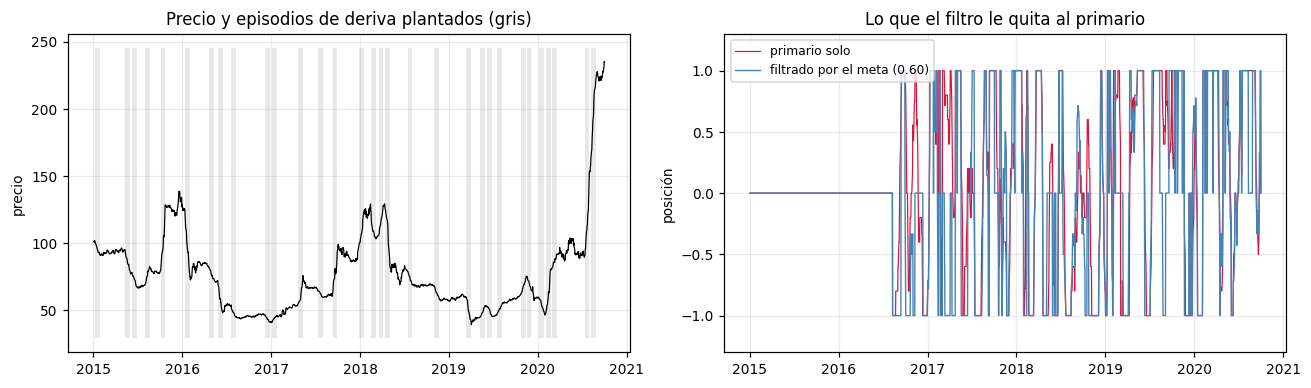

exposición del primario 0.68  ->  filtrado 0.57


In [3]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
pos_all = daily_position(sd0.bars.index, M0[ok0], np.ones(ok0.sum(), bool))
pos_f = daily_position(sd0.bars.index, M0[ok0], (p0 > 0.60)[ok0])
a1.plot(sd0.bars.index, sd0.bars.close, color="k", lw=0.8)
a1.set(ylabel="precio", title="Precio y episodios de deriva plantados (gris)")
zz = sd0.truth.z.values
a1.fill_between(sd0.bars.index, *a1.get_ylim(), where=zz != 0, color="gray", alpha=0.18, lw=0)

a2.plot(sd0.bars.index, pos_all, lw=0.8, color="crimson", label="primario solo")
a2.plot(sd0.bars.index, pos_f, lw=0.9, color="steelblue", label="filtrado por el meta (0.60)")
a2.set(ylabel="posición", title="Lo que el filtro le quita al primario", ylim=(-1.3, 1.3))
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_setup.png", bbox_inches="tight"); plt.show()

print(f"exposición del primario {(pos_all != 0).mean():.2f}  ->  filtrado {(pos_f != 0).mean():.2f}")

## 2. La afirmación del F1

Antes de medir nada hay una identidad que conviene tener delante. Si el primario apuesta en todo,
su recall es 1 y su precisión es la tasa base `p`, así que

$$F_1^{\text{primario}} = \frac{2p}{1+p}$$

Un filtro que se queda con una fracción `f` de las apuestas y acierta una proporción `q` de las
que toma tiene recall `f q / p`, y por tanto

$$F_1^{\text{filtrado}} = \frac{2 f q}{p + f}
\qquad\Longrightarrow\qquad
F_1^{\text{filtrado}} > F_1^{\text{primario}} \iff q > \frac{p\,(p+f)}{f\,(1+p)}$$

Esa desigualdad es el listón. No depende de los datos: es aritmética de la métrica. La pregunta
empírica es si un filtro real llega a él.

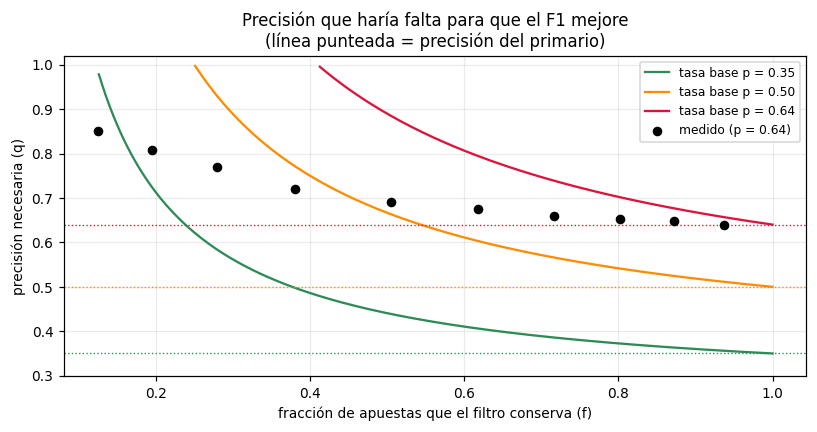

  con p=0.644 y f=0.8 haría falta precisión 0.707
  con p=0.644 y f=0.5 haría falta precisión 0.896
  con p=0.644 y f=0.3 haría falta precisión 1.232


In [4]:
def q_required(p, f):
    return p * (p + f) / (f * (1 + p))

fig, ax = plt.subplots(figsize=(7.5, 4))
ff = np.linspace(0.08, 1.0, 200)
for p, col in zip([0.35, 0.50, 0.64], ["seagreen", "darkorange", "crimson"]):
    q = q_required(p, ff)
    q[q > 1] = np.nan
    ax.plot(ff, q, color=col, label=f"tasa base p = {p:.2f}")
    ax.axhline(p, color=col, ls=":", lw=0.9)
ax.scatter(frontera["% apuestas"] / 100, frontera["precision"], color="k", zorder=5, s=28,
           label=f"medido (p = {base:.2f})")
ax.set(xlabel="fracción de apuestas que el filtro conserva (f)",
       ylabel="precisión necesaria (q)", ylim=(0.3, 1.02),
       title="Precisión que haría falta para que el F1 mejore\n(línea punteada = precisión del primario)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_f1_frontier.png", bbox_inches="tight"); plt.show()

for f_ in [0.8, 0.5, 0.3]:
    print(f"  con p={base:.3f} y f={f_:.1f} haría falta precisión {q_required(base, f_):.3f}")

In [5]:
def world_run(seed, cfg=STRONG, n_hold=N_HOLD, scheme="walk-forward", every=1,
              primary="rule", acc=0.55):
    sd, M, X = build(seed, cfg, n_hold=n_hold, every=every, primary=primary, acc=acc)
    y, rs, n = M.bin_meta.values, M.ret_side.values, len(M)
    p = oos_proba(X, y, splits_for(M, n, scheme, seed, n_hold))
    ok = ~np.isnan(p)
    Mo = M[ok]
    out = {"base_rate": y[ok].mean(),
           "auc": roc_auc_score(y[ok], p[ok]) if len(np.unique(y[ok])) > 1 else np.nan,
           "f1_primario": f1_of_always_take(y[ok].mean()),
           "sr_bet_primario": bet_metrics(rs[ok], np.ones(ok.sum(), bool), n_hold=n_hold)["sharpe"],
           "sr_time_primario": portfolio_metrics(sd.bars.index, sd.bars.close, Mo,
                                                 np.ones(len(Mo), bool))["sharpe_time"]}
    for tau in TAUS:
        take = (p > tau)[ok]
        if take.sum() < 20:
            out[f"f1|{tau}"] = out[f"srb|{tau}"] = out[f"srt|{tau}"] = np.nan
            out[f"frac|{tau}"] = out[f"prec|{tau}"] = np.nan
            continue
        cm = classification_metrics(y[ok], take)
        out[f"f1|{tau}"] = cm["f1"]; out[f"frac|{tau}"] = cm["frac_bets"]
        out[f"prec|{tau}"] = cm["precision"]
        out[f"srb|{tau}"] = bet_metrics(rs[ok], take, n_hold=n_hold)["sharpe"]
        out[f"srt|{tau}"] = portfolio_metrics(sd.bars.index, sd.bars.close, Mo, take)["sharpe_time"]
    return out

t0 = time.time()
W = over_seeds(world_run)
print(f"({time.time()-t0:.0f} s)")

f1_cols = [f"f1|{t}" for t in TAUS]
W["f1_mejor"] = W[f1_cols].max(axis=1)
W["f1_tau050"] = W["f1|0.5"]
tab = pd.DataFrame({
    "primario solo (recall = 1)": mean_ci(W.f1_primario),
    "meta, umbral 0.50": mean_ci(W.f1_tau050),
    "meta, mejor umbral de los 10 (elegido a posteriori)": mean_ci(W.f1_mejor),
}).T[["mean", "lo", "hi"]]
display(tab.round(4))
t = paired_test(W.f1_mejor, W.f1_primario)
print(f"mejor F1 alcanzable - F1 del primario: {t['diff']:+.4f} [{t['lo']:+.4f}, {t['hi']:+.4f}], "
      f"p = {t['p']:.2e}")
print(f"AUC del secundario: {fmt_ci(mean_ci(W.auc), 3)}  "
      f"(p vs 0.5 = {one_sample_test(W.auc, 0.5)['p']:.2e})")

(12 s)


,mean,lo,hi
primario solo (recall = 1),0.7434,0.7327,0.7541
"meta, umbral 0.50",0.6585,0.6406,0.6765
"meta, mejor umbral de los 10 (elegido a posteriori)",0.7262,0.7131,0.7392


mejor F1 alcanzable - F1 del primario: -0.0173 [-0.0228, -0.0117], p = 6.41e-07
AUC del secundario: 0.611 [0.600, 0.623]  (p vs 0.5 = 1.93e-18)


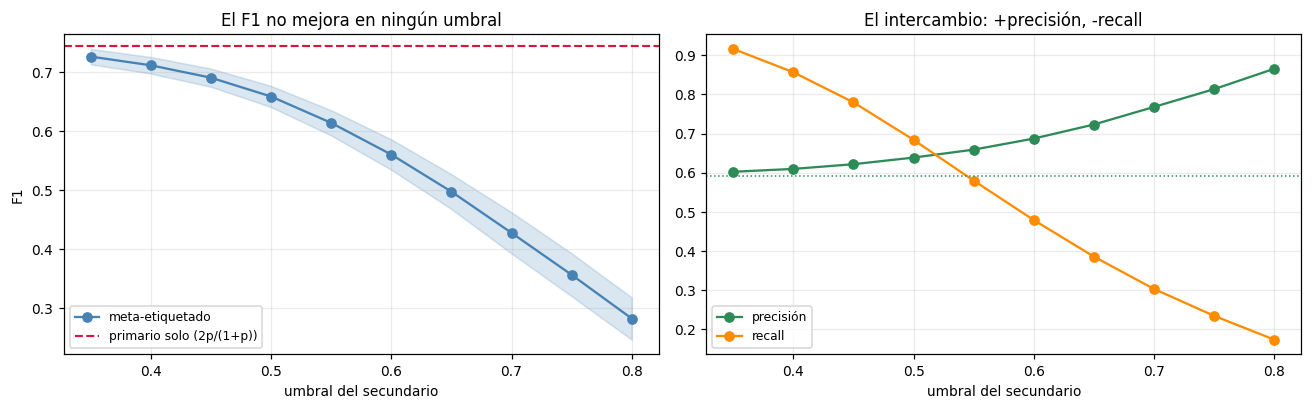

subida de precisión del umbral 0.35 al 0.80: +0.263
caída de recall en el mismo tramo:            -0.743


In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
m_f1 = [mean_ci(W[f"f1|{t}"])["mean"] for t in TAUS]
lo = [mean_ci(W[f"f1|{t}"])["lo"] for t in TAUS]
hi = [mean_ci(W[f"f1|{t}"])["hi"] for t in TAUS]
a1.plot(TAUS, m_f1, "o-", color="steelblue", label="meta-etiquetado")
a1.fill_between(TAUS, lo, hi, alpha=0.2, color="steelblue")
a1.axhline(W.f1_primario.mean(), color="crimson", ls="--", lw=1.4,
           label="primario solo (2p/(1+p))")
a1.set(xlabel="umbral del secundario", ylabel="F1", title="El F1 no mejora en ningún umbral")
a1.legend(fontsize=8)

m_p = [mean_ci(W[f"prec|{t}"])["mean"] for t in TAUS]
m_r = [mean_ci(W[f"f1|{t}"])["mean"] for t in TAUS]
rec = [mean_ci(W[f"frac|{t}"] * W[f"prec|{t}"] / W["base_rate"])["mean"] for t in TAUS]
a2.plot(TAUS, m_p, "o-", color="seagreen", label="precisión")
a2.plot(TAUS, rec, "o-", color="darkorange", label="recall")
a2.axhline(W.base_rate.mean(), color="seagreen", ls=":", lw=1)
a2.set(xlabel="umbral del secundario", ylabel="", title="El intercambio: +precisión, -recall")
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_f1.png", bbox_inches="tight"); plt.show()

print(f"subida de precisión del umbral 0.35 al 0.80: "
      f"{mean_ci(W['prec|0.8'])['mean'] - mean_ci(W['prec|0.35'])['mean']:+.3f}")
print(f"caída de recall en el mismo tramo:            "
      f"{rec[-1] - rec[0]:+.3f}")

## 3. ¿Y el dinero?

Que el F1 no mejore no significa que el meta-etiquetado no sirva: significa que el F1 no es la
métrica. La pregunta económica se puede hacer de dos formas, y **no dan lo mismo**:

* **Sharpe por apuesta** — media y desviación de los retornos de las apuestas tomadas. Es la
  métrica implícita cuando uno mira "hit rate" y "retorno medio por trade".
* **Sharpe en el tiempo** — se construye la posición en tiempo de calendario (la apuesta se
  mantiene de `t0` a `t1`, y donde se solapan varias se promedia) y se calcula el Sharpe de los
  retornos diarios de esa posición. Los días en liquidez cuentan.

La diferencia no es cosmética. El Sharpe por apuesta **premia mecánicamente la selectividad**:
tomar menos apuestas y mejores siempre lo sube, y nunca cobra por el tiempo que el capital pasa
sin usar. El Sharpe en el tiempo sí lo cobra.

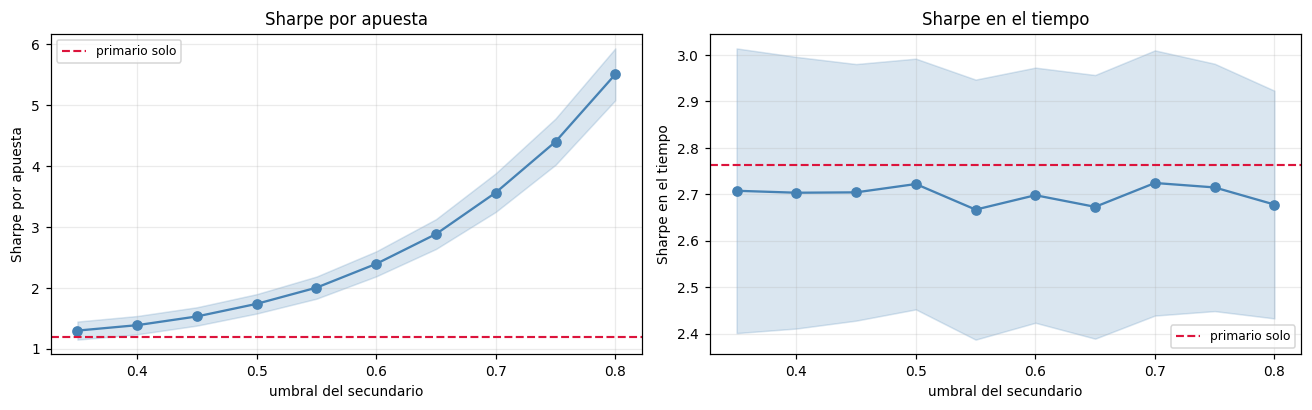

umbral que maximiza el Sharpe POR APUESTA : mediana 0.80
umbral que maximiza el Sharpe EN EL TIEMPO: mediana 0.53
coinciden en 23% de las semillas

Sharpe en el tiempo perdido por elegir el umbral con el Sharpe por apuesta: -0.377 [-0.512, -0.243]

--- umbral FIJO en 0.50 (sin elegir nada a posteriori) ---
  Sharpe por apuesta  - primario solo: +0.545 [+0.470, +0.620], p = 4.87e-15
  Sharpe en el tiempo - primario solo: -0.040 [-0.132, +0.051], p = 3.77e-01

--- MEJOR umbral de los 10 (elegido con los mismos datos) ---
  Sharpe por apuesta  - primario solo: +4.333 [+3.891, +4.775], p = 1.54e-18
  Sharpe en el tiempo - primario solo: +0.324 [+0.186, +0.462], p = 4.47e-05


In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, pre, lab, prim_col in [(a1, "srb", "Sharpe por apuesta", "sr_bet_primario"),
                               (a2, "srt", "Sharpe en el tiempo", "sr_time_primario")]:
    m = [mean_ci(W[f"{pre}|{t}"])["mean"] for t in TAUS]
    lo = [mean_ci(W[f"{pre}|{t}"])["lo"] for t in TAUS]
    hi = [mean_ci(W[f"{pre}|{t}"])["hi"] for t in TAUS]
    ax.plot(TAUS, m, "o-", color="steelblue")
    ax.fill_between(TAUS, lo, hi, alpha=0.2, color="steelblue")
    ax.axhline(W[prim_col].mean(), color="crimson", ls="--", lw=1.4, label="primario solo")
    ax.set(xlabel="umbral del secundario", ylabel=lab, title=lab)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_threshold_frontier.png", bbox_inches="tight"); plt.show()

srb_cols = [f"srb|{t}" for t in TAUS]; srt_cols = [f"srt|{t}" for t in TAUS]
best_b = W[srb_cols].idxmax(axis=1).str.split("|").str[1].astype(float)
best_t = W[srt_cols].idxmax(axis=1).str.split("|").str[1].astype(float)
print(f"umbral que maximiza el Sharpe POR APUESTA : mediana {best_b.median():.2f}")
print(f"umbral que maximiza el Sharpe EN EL TIEMPO: mediana {best_t.median():.2f}")
print(f"coinciden en {(best_b == best_t).mean()*100:.0f}% de las semillas")

# lo que cuesta elegir el umbral con la metrica equivocada
cost = np.array([W.loc[s, f"srt|{best_b[s]}"] - W.loc[s, f"srt|{best_t[s]}"] for s in W.index])
print(f"\nSharpe en el tiempo perdido por elegir el umbral con el Sharpe por apuesta: "
      f"{fmt_ci(mean_ci(cost), 3)}")
print("\n--- umbral FIJO en 0.50 (sin elegir nada a posteriori) ---")
for name, col, prim in [("por apuesta", "srb|0.5", "sr_bet_primario"),
                        ("en el tiempo", "srt|0.5", "sr_time_primario")]:
    t = paired_test(W[col], W[prim])
    print(f"  Sharpe {name:12s} - primario solo: {t['diff']:+.3f} "
          f"[{t['lo']:+.3f}, {t['hi']:+.3f}], p = {t['p']:.2e}")
print("\n--- MEJOR umbral de los 10 (elegido con los mismos datos) ---")
for name, col, prim in [("por apuesta", srb_cols, "sr_bet_primario"),
                        ("en el tiempo", srt_cols, "sr_time_primario")]:
    t = paired_test(W[col].max(axis=1), W[prim])
    print(f"  Sharpe {name:12s} - primario solo: {t['diff']:+.3f} "
          f"[{t['lo']:+.3f}, {t['hi']:+.3f}], p = {t['p']:.2e}")

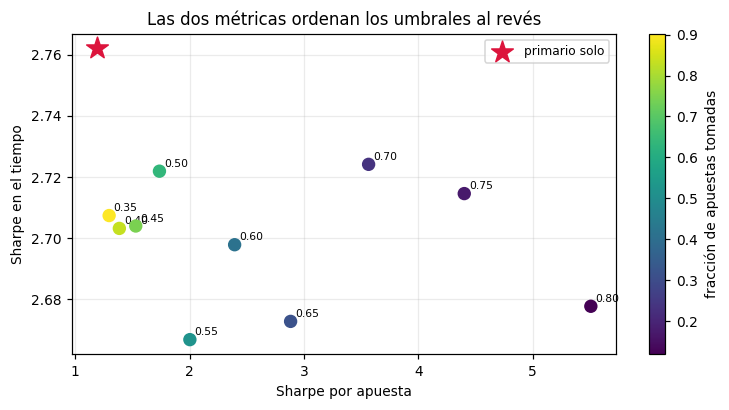

correlación de Spearman entre las dos métricas a lo largo del grid de umbrales: -0.08


In [8]:
# ¿por que divergen? porque la selectividad compra precision y paga exposicion
fig, ax = plt.subplots(figsize=(7, 3.8))
xs = [mean_ci(W[f"srb|{t}"])["mean"] for t in TAUS]
ys = [mean_ci(W[f"srt|{t}"])["mean"] for t in TAUS]
fr = [mean_ci(W[f"frac|{t}"])["mean"] for t in TAUS]
sc = ax.scatter(xs, ys, c=fr, cmap="viridis", s=60, zorder=4)
for x, y_, t_ in zip(xs, ys, TAUS):
    ax.annotate(f"{t_:.2f}", (x, y_), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.scatter([W.sr_bet_primario.mean()], [W.sr_time_primario.mean()], marker="*", s=220,
           color="crimson", zorder=5, label="primario solo")
ax.set(xlabel="Sharpe por apuesta", ylabel="Sharpe en el tiempo",
       title="Las dos métricas ordenan los umbrales al revés")
plt.colorbar(sc, ax=ax, label="fracción de apuestas tomadas")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_two_sharpes.png", bbox_inches="tight"); plt.show()

r = pd.Series(xs).corr(pd.Series(ys), method="spearman")
print(f"correlación de Spearman entre las dos métricas a lo largo del grid de umbrales: {r:+.2f}")

## 4. Filtrar no es dimensionar

Hay una asimetría escondida en todo lo anterior. Usar el secundario como **filtro** es tomar una
decisión de 0/1: o se coge la apuesta entera o no se coge nada. Pero el capítulo 10 del libro pide
otra cosa — usar la probabilidad para **dimensionar** la apuesta. Son dos usos muy distintos de la
misma información:

* **filtro**: la exposición sólo cambia en las ventanas que quedan completamente descubiertas.
  Con apuestas solapadas, quitar una no quita exposición si una vecina sigue viva — es la
  aritmética del notebook 03 reapareciendo.
* **dimensionado**: la posición es `side * f(p)` con `f` continua, así que cada apuesta pesa lo
  que el secundario cree que vale. No hay umbral, y por tanto no hay un grado de libertad más que
  elegir.

Se comparan tres reglas fijas de dimensionado — ninguna ajustada a los datos — contra el filtro, a
tres densidades de muestreo, porque si la explicación del solape es correcta la diferencia debería
encogerse cuando las apuestas dejan de solaparse.

In [9]:
EVERY = [1, 5, 10]

def filter_vs_size(seed, every):
    sd, M, X = build(seed, STRONG, every=every)
    y, n = M.bin_meta.values, len(M)
    p = oos_proba(X, y, splits_for(M, n, "walk-forward", seed))
    ok = ~np.isnan(p)
    Mo, po = M[ok], p[ok]
    allb = np.ones(len(Mo), bool)
    PM = lambda take, size=None, c=0.0: portfolio_metrics(sd.bars.index, sd.bars.close, Mo,
                                                          take, size=size, cost_bps=c)
    variants = {"primario solo": (allb, None),
                "filtro (umbral 0.50)": (po > 0.5, None),
                "filtro (umbral 0.60)": (po > 0.6, None),
                "tamaño = p": (allb, po),
                "tamaño = max(2p-1, 0)": (allb, np.clip(2 * po - 1, 0, 1))}
    out = {}
    for name, (take, size) in variants.items():
        m = PM(take, size)
        out[name] = m["sharpe_time"]
        out[f"{name}|coste5"] = PM(take, size, c=5.0)["sharpe_time"]
        out[f"{name}|rotacion"] = m["turnover"]
    return out

FS = {e: over_seeds(lambda s, e=e: filter_vs_size(s, e)) for e in EVERY}
COLS = ["filtro (umbral 0.50)", "filtro (umbral 0.60)", "tamaño = p", "tamaño = max(2p-1, 0)"]

for e in EVERY:
    D = FS[e]
    print(f"--- una observación cada {e} barra(s) --- primario solo: "
          f"{fmt_ci(mean_ci(D['primario solo']), 3)}")
    for c in COLS:
        t = paired_test(D[c], D["primario solo"])
        t5 = paired_test(D[f"{c}|coste5"], D["primario solo|coste5"])
        print(f"    {c:24s} {mean_ci(D[c])['mean']:.3f}   vs primario "
              f"{t['diff']:+.3f} [{t['lo']:+.3f}, {t['hi']:+.3f}]  p = {t['p']:.4f}"
              f"   | con 5 pb de coste: {t5['diff']:+.3f}  (rotación x"
              f"{mean_ci(D[f'{c}|rotacion'])['mean'] / mean_ci(D['primario solo|rotacion'])['mean']:.2f})")

--- una observación cada 1 barra(s) --- primario solo: 2.762 [2.476, 3.048]
    filtro (umbral 0.50)     2.722   vs primario -0.040 [-0.132, +0.051]  p = 0.3775   | con 5 pb de coste: -0.045  (rotación x1.10)
    filtro (umbral 0.60)     2.698   vs primario -0.064 [-0.181, +0.052]  p = 0.2697   | con 5 pb de coste: -0.067  (rotación x1.01)
    tamaño = p               3.076   vs primario +0.314 [+0.263, +0.365]  p = 0.0000   | con 5 pb de coste: +0.314  (rotación x0.68)
    tamaño = max(2p-1, 0)    3.215   vs primario +0.453 [+0.310, +0.596]  p = 0.0000   | con 5 pb de coste: +0.463  (rotación x0.39)
--- una observación cada 5 barra(s) --- primario solo: 1.760 [1.512, 2.008]
    filtro (umbral 0.50)     1.702   vs primario -0.059 [-0.166, +0.049]  p = 0.2746   | con 5 pb de coste: -0.053  (rotación x0.90)
    filtro (umbral 0.60)     1.712   vs primario -0.048 [-0.204, +0.108]  p = 0.5337   | con 5 pb de coste: -0.030  (rotación x0.67)
    tamaño = p               1.931   vs primario +

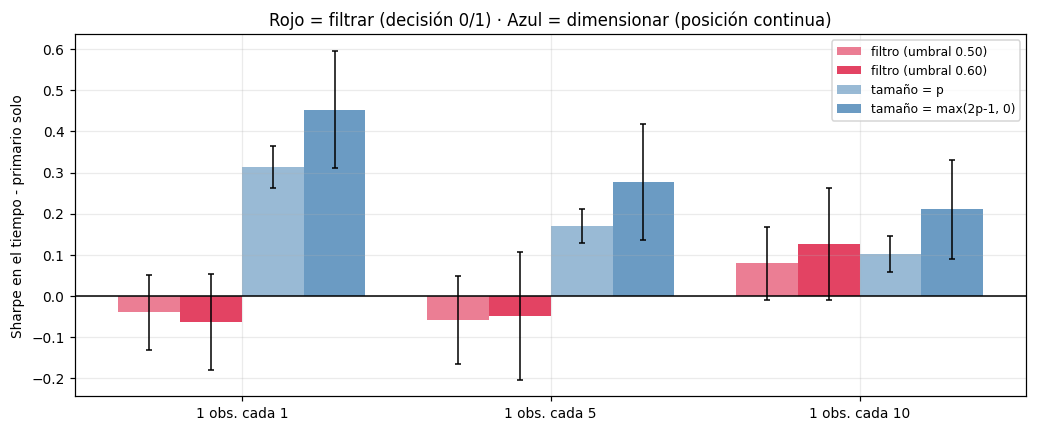

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 4))
w = 0.2
for j, c in enumerate(COLS):
    m = [paired_test(FS[e][c], FS[e]["primario solo"])["diff"] for e in EVERY]
    lo = [paired_test(FS[e][c], FS[e]["primario solo"])["lo"] for e in EVERY]
    hi = [paired_test(FS[e][c], FS[e]["primario solo"])["hi"] for e in EVERY]
    x = np.arange(len(EVERY)) + (j - 1.5) * w
    col = "crimson" if c.startswith("filtro") else "steelblue"
    ax.bar(x, m, w, color=col, alpha=0.55 + 0.25 * (j % 2), label=c)
    ax.errorbar(x, m, yerr=[np.array(m) - np.array(lo), np.array(hi) - np.array(m)],
                fmt="none", ecolor="k", lw=1, capsize=2)
ax.axhline(0, color="k", lw=1)
ax.set_xticks(range(len(EVERY)))
ax.set_xticklabels([f"1 obs. cada {e}" for e in EVERY])
ax.set(ylabel="Sharpe en el tiempo - primario solo",
       title="Rojo = filtrar (decisión 0/1) · Azul = dimensionar (posición continua)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_filter_vs_size.png", bbox_inches="tight"); plt.show()

## 5. ¿De qué depende que el meta-etiquetado sirva para algo?

Hipótesis mecanicista, en la línea de la que funcionó en el notebook 04: el secundario solo puede
aportar si **los errores del primario son predecibles a partir de los features**. Si el primario
se equivoca por razones estructurales — apuesta con momentum y el momentum solo funciona dentro de
los episodios — hay algo que aprender. Si se equivoca por ruido independiente, no lo hay, por malo
que sea.

Se contrasta con dos familias de primario a la misma calidad:

* **regla** (`sign(mom_5)`): sus errores están correlacionados con el régimen.
* **oráculo ruidoso**: apunta a la deriva verdadera con probabilidad `acc` y al revés en el resto,
  con el fallo sorteado de forma independiente. Se puede hacer arbitrariamente malo, pero sus
  errores son imposibles de anticipar.

(41 s, 15 semillas — barrido caro)


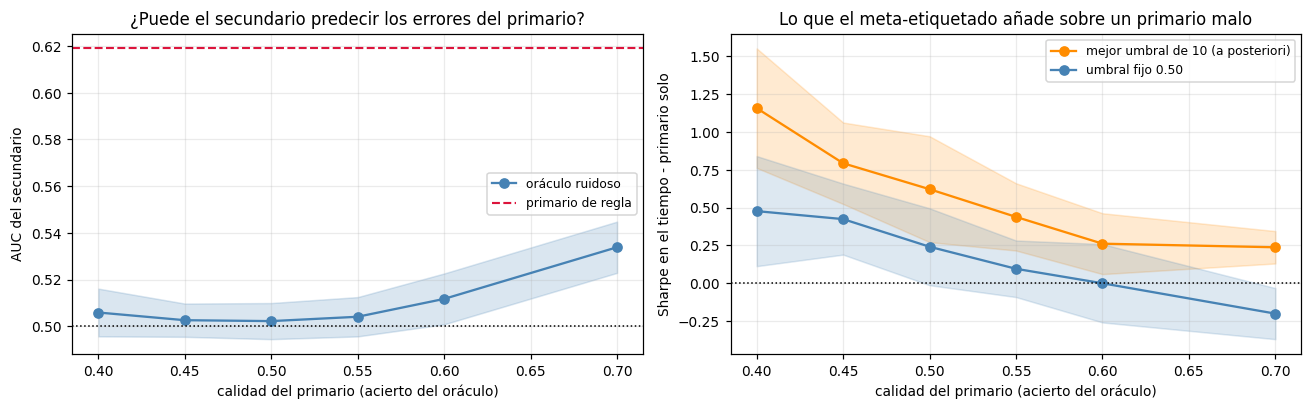

,AUC secundario,tasa base,Sharpe del primario,"ganancia, umbral fijo","ganancia, mejor umbral"
oráculo 0.40,"0.506 [0.496, 0.516]","0.478 [0.467, 0.490]","-0.98 [-1.26, -0.70]","0.477 [0.113, 0.841]","1.158 [0.763, 1.553]"
oráculo 0.45,"0.503 [0.496, 0.510]","0.490 [0.482, 0.498]","-0.49 [-0.78, -0.19]","0.424 [0.190, 0.659]","0.794 [0.524, 1.063]"
oráculo 0.50,"0.502 [0.495, 0.510]","0.504 [0.498, 0.510]","-0.04 [-0.37, 0.28]","0.242 [-0.012, 0.496]","0.622 [0.272, 0.972]"
oráculo 0.55,"0.504 [0.496, 0.513]","0.517 [0.509, 0.525]","0.44 [0.02, 0.86]","0.096 [-0.091, 0.283]","0.439 [0.217, 0.661]"
oráculo 0.60,"0.512 [0.501, 0.523]","0.527 [0.518, 0.536]","0.98 [0.58, 1.39]","0.000 [-0.259, 0.259]","0.262 [0.061, 0.463]"
oráculo 0.70,"0.534 [0.523, 0.545]","0.554 [0.541, 0.566]","1.80 [1.47, 2.13]","-0.200 [-0.369, -0.032]","0.238 [0.131, 0.345]"
regla mom_5,"0.619 [0.603, 0.635]","0.600 [0.577, 0.622]","2.99 [2.63, 3.36]","-0.098 [-0.262, 0.066]","0.258 [0.040, 0.476]"


In [11]:
ACCS = [0.40, 0.45, 0.50, 0.55, 0.60, 0.70]

def primary_family(seed):
    row = {}
    r = world_run(seed, primary="rule")
    row["regla|auc"] = r["auc"]
    row["regla|d_srt"] = np.nanmax([r[f"srt|{t}"] for t in TAUS]) - r["sr_time_primario"]
    row["regla|d_050"] = r["srt|0.5"] - r["sr_time_primario"]
    row["regla|sr_prim"] = r["sr_time_primario"]
    row["regla|base"] = r["base_rate"]
    for a in ACCS:
        r = world_run(seed, primary="oracle", acc=a)
        row[f"orac{a}|auc"] = r["auc"]
        row[f"orac{a}|d_srt"] = np.nanmax([r[f"srt|{t}"] for t in TAUS]) - r["sr_time_primario"]
        row[f"orac{a}|d_050"] = r["srt|0.5"] - r["sr_time_primario"]
        row[f"orac{a}|sr_prim"] = r["sr_time_primario"]
        row[f"orac{a}|base"] = r["base_rate"]
    return row

t0 = time.time()
PF = over_seeds(primary_family, seeds=SEEDS[:15])
print(f"({time.time()-t0:.0f} s, 15 semillas — barrido caro)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
m = [mean_ci(PF[f"orac{a}|auc"])["mean"] for a in ACCS]
lo = [mean_ci(PF[f"orac{a}|auc"])["lo"] for a in ACCS]
hi = [mean_ci(PF[f"orac{a}|auc"])["hi"] for a in ACCS]
a1.plot(ACCS, m, "o-", color="steelblue", label="oráculo ruidoso")
a1.fill_between(ACCS, lo, hi, alpha=0.2, color="steelblue")
a1.axhline(mean_ci(PF["regla|auc"])["mean"], color="crimson", ls="--", lw=1.4,
           label="primario de regla")
a1.axhline(0.5, color="k", ls=":", lw=1)
a1.set(xlabel="calidad del primario (acierto del oráculo)", ylabel="AUC del secundario",
       title="¿Puede el secundario predecir los errores del primario?")
a1.legend(fontsize=8)

for key, col, lab in [("d_srt", "darkorange", "mejor umbral de 10 (a posteriori)"),
                      ("d_050", "steelblue", "umbral fijo 0.50")]:
    m = [mean_ci(PF[f"orac{a}|{key}"])["mean"] for a in ACCS]
    lo = [mean_ci(PF[f"orac{a}|{key}"])["lo"] for a in ACCS]
    hi = [mean_ci(PF[f"orac{a}|{key}"])["hi"] for a in ACCS]
    a2.plot(ACCS, m, "o-", color=col, label=lab)
    a2.fill_between(ACCS, lo, hi, alpha=0.18, color=col)
a2.axhline(0, color="k", ls=":", lw=1)
a2.set(xlabel="calidad del primario (acierto del oráculo)",
       ylabel="Sharpe en el tiempo - primario solo",
       title="Lo que el meta-etiquetado añade sobre un primario malo")
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_primary_quality.png", bbox_inches="tight"); plt.show()

def _row(pre):
    return {"AUC secundario": fmt_ci(mean_ci(PF[f"{pre}|auc"]), 3),
            "tasa base": fmt_ci(mean_ci(PF[f"{pre}|base"]), 3),
            "Sharpe del primario": fmt_ci(mean_ci(PF[f"{pre}|sr_prim"]), 2),
            "ganancia, umbral fijo": fmt_ci(mean_ci(PF[f"{pre}|d_050"]), 3),
            "ganancia, mejor umbral": fmt_ci(mean_ci(PF[f"{pre}|d_srt"]), 3)}

display(pd.DataFrame({f"oráculo {a:.2f}": _row(f"orac{a}") for a in ACCS} |
                     {"regla mom_5": _row("regla")}).T)

## 6. El nulo: ¿inventa el meta-etiquetado una ventaja?

El notebook 04 mostró que el k-fold aleatorio reporta AUC 0.732 sobre datos donde la etiqueta es
una moneda. La pregunta aquí es si el meta-etiquetado hereda ese problema — y si el umbral, que es
un parámetro libre más, lo empeora.

Sobre datos nulos, con el mismo primario de regla, en los tres esquemas de partición.

(37 s)


,AUC del secundario,Sharpe primario,Sharpe meta (umbral 0.50),Sharpe meta (mejor umbral),p del mejor vs 0
walk-forward,0.4918,-0.1121,-0.1637,0.2336,0.0059
purgado,0.4950,-0.1095,-0.0799,0.2071,0.0085
aleatorio,0.6767,-0.1095,0.8433,1.3421,0.0000


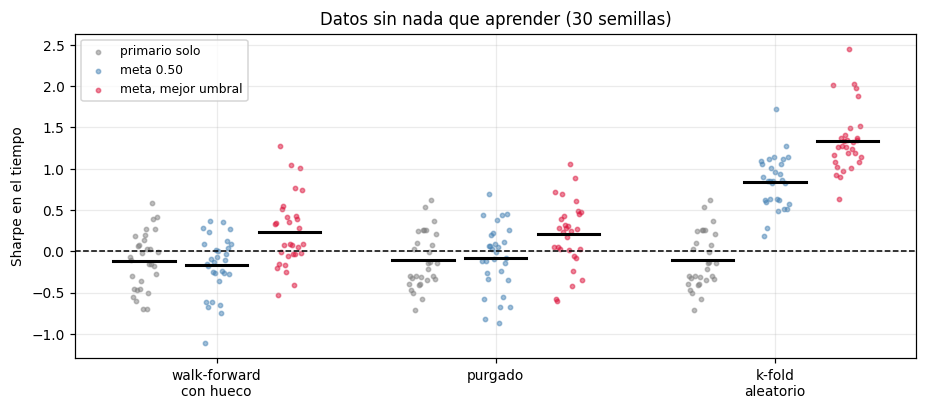

In [12]:
def null_meta(seed):
    row = {}
    for scheme in ["walk-forward", "purgado", "aleatorio"]:
        r = world_run(seed, cfg=NULL, n_hold=20, scheme=scheme)
        row[f"{scheme}|auc"] = r["auc"]
        row[f"{scheme}|srt_prim"] = r["sr_time_primario"]
        row[f"{scheme}|srt_050"] = r["srt|0.5"]
        row[f"{scheme}|srt_best"] = np.nanmax([r[f"srt|{t}"] for t in TAUS])
    return row

t0 = time.time()
NM = over_seeds(null_meta)
print(f"({time.time()-t0:.0f} s)")

rows = {}
for scheme in ["walk-forward", "purgado", "aleatorio"]:
    rows[scheme] = {"AUC del secundario": mean_ci(NM[f"{scheme}|auc"])["mean"],
                    "Sharpe primario": mean_ci(NM[f"{scheme}|srt_prim"])["mean"],
                    "Sharpe meta (umbral 0.50)": mean_ci(NM[f"{scheme}|srt_050"])["mean"],
                    "Sharpe meta (mejor umbral)": mean_ci(NM[f"{scheme}|srt_best"])["mean"],
                    "p del mejor vs 0": one_sample_test(NM[f"{scheme}|srt_best"], 0.0)["p"]}
display(pd.DataFrame(rows).T.round(4))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
lbl = ["walk-forward\ncon hueco", "purgado", "k-fold\naleatorio"]
for k, scheme in enumerate(["walk-forward", "purgado", "aleatorio"]):
    for j, (col, c_, nm) in enumerate([("srt_prim", "gray", "primario solo"),
                                       ("srt_050", "steelblue", "meta 0.50"),
                                       ("srt_best", "crimson", "meta, mejor umbral")]):
        v = NM[f"{scheme}|{col}"].values
        x = k + (j - 1) * 0.26
        ax.scatter(np.full(len(v), x) + np.linspace(-0.05, 0.05, len(v)), v, s=8, color=c_,
                   alpha=0.5, label=nm if k == 0 else None)
        ax.plot([x - 0.11, x + 0.11], [np.nanmean(v)] * 2, color="k", lw=2)
ax.axhline(0, color="k", ls="--", lw=1)
ax.set_xticks(range(3)); ax.set_xticklabels(lbl)
ax.set(ylabel="Sharpe en el tiempo", title="Datos sin nada que aprender (30 semillas)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_null.png", bbox_inches="tight"); plt.show()

## 7. La cuenta pendiente: los grados de libertad

El notebook 02 terminó con una deuda — *"son grados de libertad, y el notebook 05 tiene que
contarlos"*. Recapitulando lo que este proyecto ha ido eligiendo sin justificar del todo:

| elección | dónde apareció | opciones razonables |
|---|---|---|
| multiplicadores de barrera `pt_sl` | nb 02 §5 | `(1,1)`, `(2,1)`, `(1,2)`, `(0.5,0.5)` |
| horizonte vertical `N` | nb 02, 03 | 10, 20, 40 |
| densidad de muestreo | nb 03 | todas las barras / CUSUM 2σ |
| umbral del secundario | este notebook | 10 valores |

Son **4 × 3 × 2 × 10 = 240 configuraciones** nominales — algunas se caen por quedarse sin apuestas
suficientes, y quedan unas 185 evaluables — todas defendibles, ninguna elegida por adelantado.
El experimento: correr la rejilla entera **sobre datos nulos**, quedarse con la mejor y ver qué
pinta tiene. Se mide de tres formas: el máximo *in-sample*, el fuera de muestra de esa misma
configuración (partiendo la serie por la mitad), y el `E[max SR]` que predice la teoría del
Sharpe deflactado.

In [13]:
PT_GRID = [(1.0, 1.0), (2.0, 1.0), (1.0, 2.0), (0.5, 0.5)]
NH_GRID = [10, 20, 40]
SAMP_GRID = ["todas", "cusum2"]

def dof_trials(seed):
    """Retornos diarios de cada configuracion de la rejilla, sobre datos nulos."""
    sd = simulate(NULL.with_(seed=seed))
    c = sd.bars.close
    r = c.pct_change().fillna(0.0).values
    out = {}
    for pt, nh, sm in itertools.product(PT_GRID, NH_GRID, SAMP_GRID):
        sigma_h = ewma_vol(c) * np.sqrt(nh)
        pool = c.index[60:-(nh + 1)]
        ev = pool if sm == "todas" else cusum_events(c, 2 * ewma_vol(c)).intersection(pool)
        if len(ev) < 120:
            continue
        L = triple_barrier(sd.bars, ev, sigma_h, pt, nh, mode="path", fine=sd.fine,
                           vertical_label="sign")
        M = meta_labels(L, rule_side(sd.features, L.index))
        X = sd.features.reindex(M.index)[FEATS]
        okf = X.notna().all(axis=1).values
        M, X = M[okf], X.values[okf]
        p = oos_proba(X, M.bin_meta.values, list(walk_forward_gapped(len(M), K_FOLDS, gap=nh)))
        ok = ~np.isnan(p)
        Mo = M[ok]
        for tau in TAUS:
            take = (p > tau)[ok]
            if take.sum() < 20:
                continue
            pos = daily_position(sd.bars.index, Mo, take)
            out[f"pt{pt}|N{nh}|{sm}|t{tau}"] = pos.shift(1).fillna(0.0).values * r
    return pd.DataFrame(out, index=sd.bars.index)

t0 = time.time()
dof_rows = []
example = None
for s in SEEDS:
    R = dof_trials(s)
    if example is None:
        example = R
    half = len(R) // 2
    sr_is = R.iloc[:half].apply(sharpe)
    sr_os = R.iloc[half:].apply(sharpe)
    sr_all = R.apply(sharpe)
    best_is = sr_is.idxmax()
    cc = R.corr().values
    rho = (cc.sum() - len(cc)) / (len(cc) ** 2 - len(cc))
    dof_rows.append({"K": R.shape[1], "max_is": sr_is.max(), "os_del_mejor_is": sr_os[best_is],
                     "media_os": sr_os.mean(), "max_os": sr_os.max(),
                     "sd_entre_config": sr_is.std(), "max_total": sr_all.max(),
                     "E_max_teorico": expected_max_sharpe(R.shape[1], sr_is.std()),
                     "dsr_del_mejor": deflated_sharpe(R[sr_all.idxmax()].values, R.shape[1],
                                                      sr_all.std())["dsr"],
                     "corr_media": rho})
DOF = pd.DataFrame(dof_rows, index=SEEDS)
DOF.index.name = "seed"
print(f"({time.time()-t0:.0f} s)  configuraciones evaluadas por semilla: {DOF.K.iloc[0]}")
display(summarise(DOF).round(3)[["mean", "lo", "hi"]])

(244 s)  configuraciones evaluadas por semilla: 183


,mean,lo,hi
K,186.0330,181.2700,190.7970
max_is,1.0860,0.9500,1.2220
os_del_mejor_is,-0.1030,-0.3620,0.1550
media_os,-0.0320,-0.1790,0.1160
max_os,1.1220,0.9570,1.2880
sd_entre_config,0.4860,0.4380,0.5340
max_total,0.7780,0.6710,0.8840
E_max_teorico,1.3310,1.2000,1.4610
dsr_del_mejor,0.3980,0.3110,0.4850
corr_media,0.3510,0.3250,0.3760


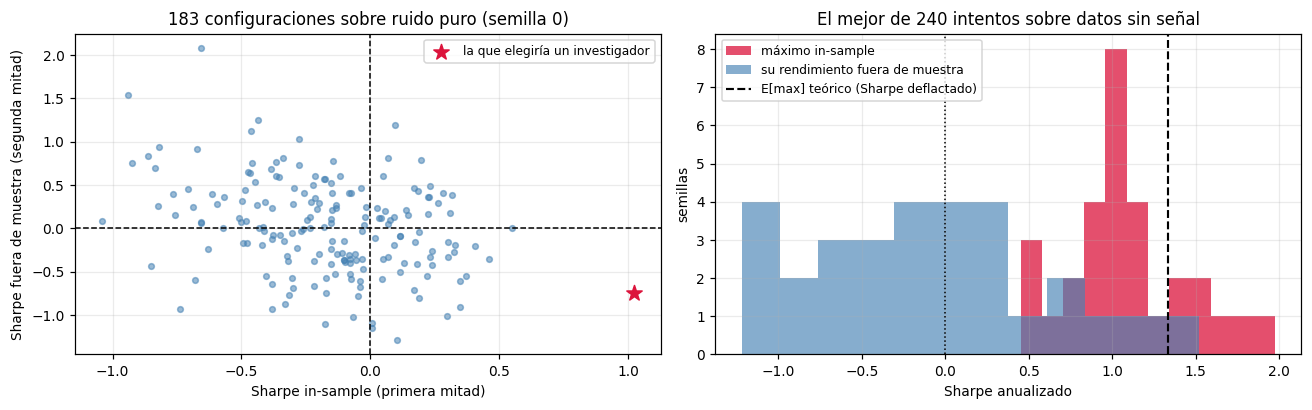

máximo in-sample sobre ruido        : 1.086 [0.950, 1.222]
E[max] que predice la teoría        : 1.331 [1.200, 1.461]
fuera de muestra de esa misma config: -0.103 [-0.362, 0.155]
media fuera de muestra de todas     : -0.032 [-0.179, 0.116]
correlación media entre configuraciones: 0.351 [0.325, 0.376]
DSR del mejor a muestra completa    : 0.398 [0.311, 0.485]

caída in-sample -> fuera de muestra: +1.190 [+0.913, +1.467], p = 1.15e-09


In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
half = len(example) // 2
sr_is = example.iloc[:half].apply(sharpe)
sr_os = example.iloc[half:].apply(sharpe)
a1.scatter(sr_is, sr_os, s=14, alpha=0.55, color="steelblue")
a1.scatter([sr_is.max()], [sr_os[sr_is.idxmax()]], s=110, marker="*", color="crimson",
           zorder=5, label="la que elegiría un investigador")
a1.axhline(0, color="k", ls="--", lw=1); a1.axvline(0, color="k", ls="--", lw=1)
a1.set(xlabel="Sharpe in-sample (primera mitad)", ylabel="Sharpe fuera de muestra (segunda mitad)",
       title=f"{example.shape[1]} configuraciones sobre ruido puro (semilla 0)")
a1.legend(fontsize=8)

a2.hist(DOF.max_is, bins=12, alpha=0.75, color="crimson", label="máximo in-sample")
a2.hist(DOF.os_del_mejor_is, bins=12, alpha=0.65, color="steelblue",
        label="su rendimiento fuera de muestra")
a2.axvline(DOF.E_max_teorico.mean(), color="k", ls="--", lw=1.4,
           label="E[max] teórico (Sharpe deflactado)")
a2.axvline(0, color="k", ls=":", lw=1)
a2.set(xlabel="Sharpe anualizado", ylabel="semillas",
       title="El mejor de 240 intentos sobre datos sin señal")
a2.legend(fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "05_dof.png", bbox_inches="tight"); plt.show()

print(f"máximo in-sample sobre ruido        : {fmt_ci(mean_ci(DOF.max_is), 3)}")
print(f"E[max] que predice la teoría        : {fmt_ci(mean_ci(DOF.E_max_teorico), 3)}")
print(f"fuera de muestra de esa misma config: {fmt_ci(mean_ci(DOF.os_del_mejor_is), 3)}")
print(f"media fuera de muestra de todas     : {fmt_ci(mean_ci(DOF.media_os), 3)}")
print(f"correlación media entre configuraciones: {fmt_ci(mean_ci(DOF.corr_media), 3)}")
print(f"DSR del mejor a muestra completa    : {fmt_ci(mean_ci(DOF.dsr_del_mejor), 3)}")
t = paired_test(DOF.max_is, DOF.os_del_mejor_is)
print(f"\ncaída in-sample -> fuera de muestra: {t['diff']:+.3f} [{t['lo']:+.3f}, {t['hi']:+.3f}], "
      f"p = {t['p']:.2e}")

## 8. Predicción vs resultado

In [15]:
t_f1 = paired_test(W.f1_mejor, W.f1_primario)
t_srb = paired_test(W[srb_cols].max(axis=1), W.sr_bet_primario)
t_srt = paired_test(W[srt_cols].max(axis=1), W.sr_time_primario)
t_fix = paired_test(W["srt|0.5"], W.sr_time_primario)
t_size = paired_test(FS[1]["tamaño = max(2p-1, 0)"], FS[1]["primario solo"])
display(pd.DataFrame([
    {"magnitud": "F1: mejor meta - primario solo", "predicho": "+0.03 a +0.08",
     "obtenido": f"{t_f1['diff']:+.4f} [{t_f1['lo']:+.4f}, {t_f1['hi']:+.4f}]"},
    {"magnitud": "Sharpe POR APUESTA: mejor meta - primario", "predicho": "sube",
     "obtenido": f"{t_srb['diff']:+.3f} [{t_srb['lo']:+.3f}, {t_srb['hi']:+.3f}]"},
    {"magnitud": "Sharpe EN EL TIEMPO: mejor meta - primario", "predicho": "sube igual",
     "obtenido": f"{t_srt['diff']:+.3f} [{t_srt['lo']:+.3f}, {t_srt['hi']:+.3f}]"},
    {"magnitud": "Sharpe EN EL TIEMPO: meta a umbral fijo 0.50 - primario", "predicho": "sube",
     "obtenido": f"{t_fix['diff']:+.3f} [{t_fix['lo']:+.3f}, {t_fix['hi']:+.3f}] "
                 f"(p = {t_fix['p']:.2f})"},
    {"magnitud": "Sharpe EN EL TIEMPO: dimensionar en vez de filtrar", "predicho": "igual",
     "obtenido": f"{t_size['diff']:+.3f} [{t_size['lo']:+.3f}, {t_size['hi']:+.3f}]"},
    {"magnitud": "Sharpe nulo, walk-forward (mejor umbral)", "predicho": "~0",
     "obtenido": fmt_ci(mean_ci(NM["walk-forward|srt_best"]), 3)},
    {"magnitud": "Sharpe nulo, k-fold aleatorio (mejor umbral)", "predicho": "inflado",
     "obtenido": fmt_ci(mean_ci(NM["aleatorio|srt_best"]), 3)},
    {"magnitud": "mejor de ~185 configuraciones sobre ruido (in-sample)", "predicho": "~1.0",
     "obtenido": fmt_ci(mean_ci(DOF.max_is), 3)},
    {"magnitud": "su Sharpe fuera de muestra", "predicho": "~0",
     "obtenido": fmt_ci(mean_ci(DOF.os_del_mejor_is), 3)},
]).set_index("magnitud"))

,predicho,obtenido
magnitud,,
F1: mejor meta - primario solo,+0.03 a +0.08,"-0.0173 [-0.0228, -0.0117]"
Sharpe POR APUESTA: mejor meta - primario,sube,"+4.333 [+3.891, +4.775]"
Sharpe EN EL TIEMPO: mejor meta - primario,sube igual,"+0.324 [+0.186, +0.462]"
Sharpe EN EL TIEMPO: meta a umbral fijo 0.50 - primario,sube,"-0.040 [-0.132, +0.051] (p = 0.38)"
Sharpe EN EL TIEMPO: dimensionar en vez de filtrar,igual,"+0.453 [+0.310, +0.596]"
"Sharpe nulo, walk-forward (mejor umbral)",~0,"0.234 [0.073, 0.395]"
"Sharpe nulo, k-fold aleatorio (mejor umbral)",inflado,"1.342 [1.196, 1.488]"
mejor de ~185 configuraciones sobre ruido (in-sample),~1.0,"1.086 [0.950, 1.222]"
su Sharpe fuera de muestra,~0,"-0.103 [-0.362, 0.155]"


### Veredicto

**1. El F1 no mejora. Nunca, en ningún umbral, y no por poco.** El mejor F1 alcanzable barriendo
los diez umbrales — un número ya optimista, porque se elige a posteriori — queda **-0.0173**
[-0.0228, -0.0117] **por debajo** del primario solo (p = 6e-07). Y no es que el modelo secundario
sea malo: tiene habilidad real y medible, AUC **0.611** [0.600, 0.623], p ~ 2e-18. Es que la
métrica no puede subir. Con recall 1 de partida, el listón es `2p/(1+p)` = 0.783, y la desigualdad
de la sección 2 dice cuánta precisión haría falta: con `p = 0.644`, conservar la mitad de las
apuestas exigiría precisión **0.896**, y conservar el 30% exigiría **1.232**, que no existe. El
filtro hace lo que se le pide — la precisión sube +0.263 del umbral 0.35 al 0.80 — pero el recall
se desploma -0.743. **El argumento del "high F1" de AFML no se sostiene en este montaje, y el
motivo es aritmético, no empírico.**

**2. El dinero sí mejora — según cómo se mida, que es el problema.** Con el umbral fijo en 0.50,
el Sharpe **por apuesta** sube **+0.545** [+0.470, +0.620] (p = 5e-15) y el Sharpe **en el tiempo**
no se mueve: **-0.040** [-0.132, +0.051], p = 0.38. Las dos métricas ni siquiera ordenan igual los
umbrales: correlación de Spearman **-0.08**, y el umbral óptimo coincide en el **23%** de las
semillas. Elegirlo con el Sharpe por apuesta cuesta **-0.377** [-0.512, -0.243] de Sharpe real.
El Sharpe por apuesta premia mecánicamente la selectividad porque nunca cobra el tiempo en
liquidez; es la métrica equivocada y aquí se ve exactamente cuánto engaña.

**3. Y la "ganancia" que quedaba era el propio umbral.** El mejor umbral de diez daba +0.324
[+0.186, +0.462] de Sharpe en el tiempo, que parecía un resultado. A umbral fijo es cero. Los
+0.324 eran sesgo de selección sobre diez intentos — el mismo fenómeno que la sección 7 mide a lo
grande, apareciendo aquí en pequeño.

**4. La idea del libro es buena; lo que falla es la versión binaria.** Usar la misma probabilidad
para **dimensionar** en vez de para filtrar, con una regla fija y sin ningún umbral que elegir,
sí paga: `size = max(2p-1, 0)` da **+0.453** [+0.310, +0.596] de Sharpe en el tiempo, y aguanta a
las tres densidades de muestreo (+0.278 con 1 obs./5 barras, +0.211 con 1/10). El filtro no da
nada en ninguna (-0.040, -0.059, +0.079). La razón es la aritmética del notebook 03: con apuestas
solapadas, **quitar una apuesta no quita exposición** si una vecina sigue viva, así que la decisión
0/1 tira la información sin cobrarse el beneficio. Dimensionar la conserva. Esta es la conclusión
accionable del notebook, y va justo en contra del encuadre binario del capítulo 3.

**5. El secundario solo puede aportar si los errores del primario son predecibles.** Con el
primario de regla, cuyos fallos están atados al régimen, el secundario alcanza AUC **0.619**
[0.603, 0.635]. Con oráculos ruidosos — que se pueden hacer arbitrariamente malos, pero fallan de
forma independiente — el AUC se queda entre **0.502 y 0.534** por muy malo que sea el primario.
La calidad del primario no es la variable relevante: lo es la **estructura de sus errores**.

**6. Ojo con leer una subida de Sharpe como aprendizaje.** La misma tabla contiene una trampa que
casi cuela: el oráculo peor (acierto 0.40, Sharpe **-0.98**) muestra **+0.477** de ganancia a
umbral fijo con un AUC de 0.506, o sea con cero capacidad de discriminar. No aprendió nada —
simplemente apagó a medias una estrategia que perdía dinero. La ganancia decrece monótonamente
con la calidad del primario y se vuelve **negativa** (-0.200) cuando el primario es bueno. Antes
de atribuir una mejora de Sharpe al meta-modelo hay que comprobar que el primario no estaba
perdiendo.

**7. El meta-etiquetado no protege de nada de lo del notebook 04.** Sobre datos nulos, con umbral
fijo, la validación honesta no encuentra nada (walk-forward -0.164, purgado -0.080) y el k-fold
aleatorio reporta un Sharpe de **+0.843** con AUC 0.677. La fuga atraviesa el meta-etiquetado sin
inmutarse. Peor: **elegir el mejor de diez umbrales inventa ventaja incluso con validación
honesta** — 0.234 [0.073, 0.395], p = 0.006 en walk-forward sobre datos donde no hay nada. El
umbral es un grado de libertad, y los grados de libertad cuestan aunque la partición sea correcta.

**8. La cuenta que dejó pendiente el notebook 02.** 240 configuraciones nominales, ~186
evaluables, todas defendibles: multiplicadores de barrera, horizonte, densidad de muestreo,
umbral. Sobre **ruido puro**, la mejor da un Sharpe in-sample de **1.086** [0.950, 1.222] — un
número que cualquiera enseñaría. Fuera de muestra, esa misma configuración da **-0.103**
[-0.362, +0.155]. La caída es de **1.190** [0.913, 1.467], p ~ 1e-09. No hay ninguna señal en esos
datos: el 1.086 es enteramente el precio de haber mirado 186 veces.

**9. Y la corrección teórica funciona, por el lado seguro.** La fórmula del Sharpe deflactado
predice `E[max]` = **1.331** [1.200, 1.461] frente al 1.086 observado: sobreestima, que es la
dirección conservadora, y tiene explicación — la fórmula supone intentos independientes y estas
configuraciones correlacionan **0.351** de media entre sí, así que el máximo efectivo es menor que
el de 186 intentos independientes. El DSR del mejor a muestra completa sale **0.398**: se niega
correctamente a declararlo real.

**Lo que no quedó demostrado.**
* **Que el meta-etiquetado no pueda mejorar el F1 en general.** El listón `2p/(1+p)` depende de la
  tasa base, y aquí es alta (0.644). Con un primario de tasa base 0.3 el listón baja a 0.46 y
  quedaría sitio de sobra. No he barrido la tasa base, así que el resultado es "no mejora *aquí*",
  no "no puede mejorar".
* **Las reglas de dimensionado son tres, fijas y elegidas a mano.** El capítulo 10 propone una
  política de tamaño bastante más elaborada; que la mía gane al filtro no dice que sea la mejor.
* **El coste.** Aquí el resultado salió al revés de lo que temía: dimensionar **rota menos** que
  filtrar (x0.39 de la rotación del primario, frente a x1.10 del filtro al umbral 0.50), porque una
  posición continua se mueve más suave que una decisión 0/1. La ventaja aguanta y crece un poco a
  5 pb (+0.463). Pero es un modelo de coste plano sobre rotación, sin impacto de mercado ni
  horquilla variable, y no he barrido el nivel de coste.
* **El primario es una regla, no un modelo entrenado.** Un primario ajustado podría tener errores
  más o menos predecibles que `sign(mom_5)`, y la sección 5 dice justamente que eso es lo único
  que importa.
* **Barreras simétricas en todo el notebook principal.** `sided_triple_barrier` implementa el caso
  asimétrico —donde el take-profit de un corto está debajo de la entrada— pero no lo he barrido.
* **186 es una cota inferior de los grados de libertad.** No cuenta el conjunto de features, la
  clase de modelo, sus hiperparámetros, el detector de toque ni la convención de la vertical. El
  espacio real de elecciones de este proyecto es bastante mayor que el que he sabido contar.